# 02 — Semivariograma do resíduo

**Pergunta:** o resíduo de um ponto prevê o do vizinho?

O semivariograma responde medindo, para cada distância *h*, o quanto os resíduos de pares de pontos diferem:

γ(h) = ½ · média de (r_i − r_j)²  sobre os pares a distância h

- γ baixo = pontos parecidos. γ alto = pontos diferentes.
- Se γ **cresce com h**, o resíduo tem estrutura espacial.
- O valor de γ em h ≈ 0 é o **nugget**: ruído sem estrutura (erro de medida incluído).

## Passo 1 — Preparar (igual ao notebook 01)

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

from src.processing.fusion import load_sandwell, build_observations

sandwell = load_sandwell()
obs, info = build_observations("ok", "add", sandwell)
print(obs["source"].value_counts())

source
marine    64565
CPRM       2816
RGFB        107
Name: count, dtype: int64


## Passo 2 — Coordenadas em km

Distância em graus não serve (1° de longitude ≠ 1° de latitude). Convertemos para km com uma aproximação plana, boa nesta área.

In [2]:
lat0 = obs["lat"].mean()
obs["x"] = obs["lon"] * 111.32 * np.cos(np.radians(lat0))
obs["y"] = obs["lat"] * 111.0

mar = obs[obs["source"] == "marine"].sample(4000, random_state=0)   # amostra: são 64 mil pontos
terra = obs[obs["source"] == "CPRM"]
print("mar:", len(mar), " terra:", len(terra))

mar: 4000  terra: 2816


## Passo 3 — A função do semivariograma

Passos dentro dela:
1. `query_pairs` acha todos os pares de pontos a menos de `bins[-1]` km.
2. Para cada par: distância `d` e `g = ½ (r_i − r_j)²`.
3. Agrupa os pares por faixa de distância e tira a média de `g` em cada faixa.

In [4]:
def semivariograma(x, y, r, bins):
    pontos = np.column_stack([x, y])
    pares = cKDTree(pontos).query_pairs(r=bins[-1], output_type="ndarray")
    i, j = pares[:, 0], pares[:, 1]
    d = np.hypot(x[i] - x[j], y[i] - y[j])
    g = 0.5 * (r[i] - r[j]) ** 2
    faixa = np.digitize(d, bins) - 1
    nb = len(bins) - 1
    gamma = np.full(nb, np.nan)
    n = np.zeros(nb, dtype=int)
    for b in range(nb):
        sel = faixa == b
        n[b] = sel.sum()
        if n[b] > 0:
            gamma[b] = g[sel].mean()
    centros = 0.5 * (bins[:-1] + bins[1:])
    return centros, gamma, n

## Passo 4 — Calcular para mar e terra

In [5]:
bins_mar = np.arange(0, 201, 10)     # km
bins_terra = np.arange(0, 101, 5)    # km

h_m, g_m, n_m = semivariograma(mar["x"].values, mar["y"].values, mar["r"].values, bins_mar)
h_t, g_t, n_t = semivariograma(terra["x"].values, terra["y"].values, terra["r"].values, bins_terra)

print("pares por faixa (mar): ", n_m)
print("pares por faixa (terra):", n_t)

pares por faixa (mar):  [49386 46542 47468 48729 53155 56037 58748 63533 59021 65944 61928 61514
 60087 61003 64796 65691 65764 66543 65622 69566]
pares por faixa (terra): [21183 34258 39009 38578 37679 40219 41354 44357 44200 43423 41668 39662
 38818 41994 42752 42776 40292 39471 39462 40013]


## Passo 5 — Gráfico

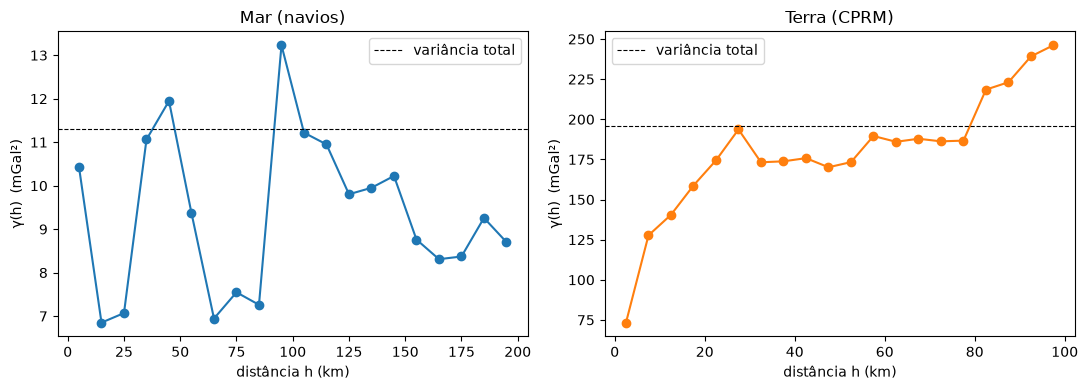

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4))

axs[0].plot(h_m, g_m, "o-", color="tab:blue")
axs[0].axhline(mar["r"].var(), color="k", ls="--", lw=0.8, label="variância total")
axs[0].set_title("Mar (navios)")

axs[1].plot(h_t, g_t, "o-", color="tab:orange")
axs[1].axhline(terra["r"].var(), color="k", ls="--", lw=0.8, label="variância total")
axs[1].set_title("Terra (CPRM)")

for ax in axs:
    ax.set_xlabel("distância h (km)")
    ax.set_ylabel("γ(h)  (mGal²)")
    ax.legend()
plt.tight_layout()
plt.show()

**Para observar:**

- Onde a curva começa (h ≈ 0)? Esse é o nugget.
- A curva sobe e depois achata na linha tracejada? A distância em que ela achata é o **alcance**: além dela, o resíduo de um ponto não diz mais nada sobre o vizinho.
- Mar e terra têm nuggets e alcances parecidos?

**Pergunta para você:** o nugget de terra é grande ou pequeno em comparação com o σ = 2,4 mGal do log de 23/09? (σ² = 5,8 mGal²; o nugget está em mGal², então compare com esse número, e não com 2,4.)

## Passo 6 — Nugget de terra com faixas finas

Até aqui a primeira faixa da terra era 0–5 km: o "nugget" de ~70 mGal² é a média de tudo dentro dela. Agora olhamos só até 10 km, em faixas de 1 km (e uma de 0–0,5 km).

**Pergunta:** γ já é ~70 mGal² nos pares mais próximos, ou sobe aos poucos de perto para longe?

In [7]:
bins_fino = np.array([0, 0.5, 1, 2, 3, 4, 5, 6, 8, 10])   # km

h_f, g_f, n_f = semivariograma(terra["x"].values, terra["y"].values, terra["r"].values, bins_fino)

tab = pd.DataFrame({"h_centro_km": h_f, "gamma_mGal2": g_f.round(1), "n_pares": n_f})
print(tab.to_string(index=False))

 h_centro_km  gamma_mGal2  n_pares
        0.25          4.8      482
        0.75         14.9     1644
        1.50         38.8     3929
        2.50         70.1     4467
        3.50         94.4     5137
        4.50        104.3     5524
        5.50        112.7     6148
        7.00        127.9    13319
        9.00        133.8    14791


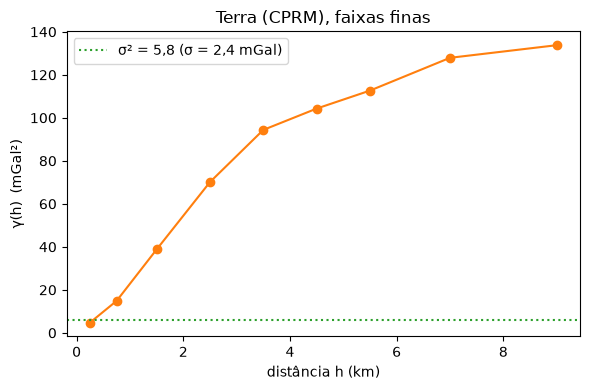

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(h_f, g_f, "o-", color="tab:orange")
ax.axhline(5.8, color="tab:green", ls=":", label="σ² = 5,8 (σ = 2,4 mGal)")
ax.set_xlabel("distância h (km)")
ax.set_ylabel("γ(h)  (mGal²)")
ax.set_title("Terra (CPRM), faixas finas")
ax.legend()
plt.tight_layout()
plt.show()

**Para observar:**

- Quantos pares há na faixa 0–0,5 km? Se forem poucos, essa faixa não é confiável.
- γ perto de 0 fica perto da linha verde (5,8) ou muito acima?
- Se γ já é alto em 0–1 km, o erro está nas próprias medidas (ou no que o Sandwell não vê). Se sobe devagar, a maior parte dos ~70 é sinal de escala curta.

Rode o passo 6 e me diga só o que vê na tabela: γ e n_pares nas duas primeiras linhas.

nugget = 50.0 mGal²   patamar = 177.6 mGal²   alcance = 22.9 km


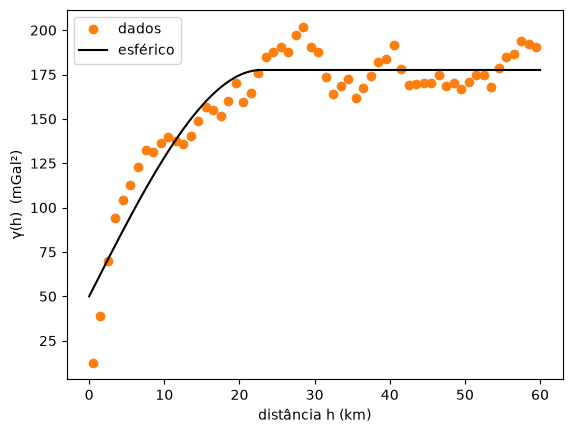

In [9]:
from scipy.optimize import curve_fit

def esferico(h, nugget, patamar, alcance):
    h = np.asarray(h, dtype=float)
    dentro = nugget + (patamar - nugget) * (1.5 * h / alcance - 0.5 * (h / alcance) ** 3)
    return np.where(h < alcance, dentro, patamar)

# faixas de 1 km até 60 km (acima de ~80 km entra a tendência regional, que o modelo não tem)
bins_aj = np.arange(0, 61, 1.0)
h_a, g_a, n_a = semivariograma(terra["x"].values, terra["y"].values, terra["r"].values, bins_aj)
ok = ~np.isnan(g_a)

p, _ = curve_fit(esferico, h_a[ok], g_a[ok], p0=[5, 180, 28], sigma=1/np.sqrt(n_a[ok]), bounds=(0, [50, 400, 100]))
print(f"nugget = {p[0]:.1f} mGal²   patamar = {p[1]:.1f} mGal²   alcance = {p[2]:.1f} km")

hh = np.linspace(0, 60, 300)
plt.plot(h_a, g_a, "o", color="tab:orange", label="dados")
plt.plot(hh, esferico(hh, *p), "k-", label="esférico")
plt.xlabel("distância h (km)"); plt.ylabel("γ(h)  (mGal²)"); plt.legend(); plt.show()

nugget = 0.0   curta: patamar 90.1, alcance 5.6 km   longa: patamar 88.1, alcance 28.6 km
patamar total = 178.2


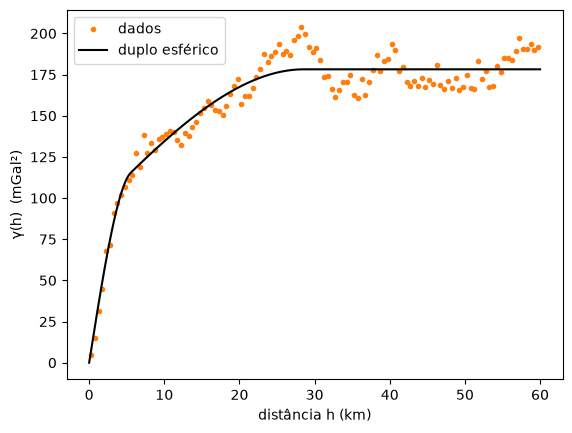

In [10]:
def esf1(h, patamar, alcance):
    h = np.asarray(h, dtype=float)
    return np.where(h < alcance, patamar * (1.5 * h / alcance - 0.5 * (h / alcance) ** 3), patamar)

def duplo(h, nugget, s1, a1, s2, a2):
    return nugget + esf1(h, s1, a1) + esf1(h, s2, a2)

# faixas de 0,5 km até 60 km, para resolver bem o começo da curva
bins_aj = np.arange(0, 60.5, 0.5)
h_a, g_a, n_a = semivariograma(terra["x"].values, terra["y"].values, terra["r"].values, bins_aj)
ok = ~np.isnan(g_a)

p, _ = curve_fit(duplo, h_a[ok], g_a[ok], p0=[5, 120, 8, 50, 28],
                 sigma=1/np.sqrt(n_a[ok]), bounds=(0, [200, 400, 15, 400, 60]))
print(f"nugget = {p[0]:.1f}   curta: patamar {p[1]:.1f}, alcance {p[2]:.1f} km   longa: patamar {p[3]:.1f}, alcance {p[4]:.1f} km")
print("patamar total =", round(p[0] + p[1] + p[3], 1))

hh = np.linspace(0, 60, 400)
plt.plot(h_a, g_a, "o", ms=3, color="tab:orange", label="dados")
plt.plot(hh, duplo(hh, *p), "k-", label="duplo esférico")
plt.xlabel("distância h (km)"); plt.ylabel("γ(h)  (mGal²)"); plt.legend(); plt.show()